# MTA bus ACE violations — profile, repeat offenders, map, decay curves

Dataset: **MTA Bus Automated Camera Enforcement Violations: Beginning October 2019**,
data.ny.gov `kh8p-hcbm`, pulled 2026-09-25 with `scripts/fetch_ace.py`
(6,532,000 rows, rows last updated 2026-08-28). Route geometry comes from MTA static
GTFS (`scripts/build_routes.py`).

Works through `research/directions.md`:

1. Profile the dataset and present the key findings
2. Repeat offenders: one lane or many, and is there a daily / periodic pattern?
3. Map of ticket concentration with the main routes highlighted → `out/ace_violations_map.html`
4. Decay curve per camera with sufficient history, plus a repeat-offender line

**Unit of analysis.** ACE cameras are mounted on buses, not on poles, so there is no
fixed camera ID in this file. A route's camera program switches on as a unit; the
*route* is used as the "camera" throughout, and its activation date is its first
issued ticket.

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mt

pd.set_option("display.width", 160)
ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
RAW, DATA, OUT = (os.path.join(ROOT, d) for d in ("data/raw", "data", "out"))
os.makedirs(OUT, exist_ok=True)

# Reference palette (dataviz skill, light mode)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
from matplotlib.colors import LinearSegmentedColormap
BLUES = LinearSegmentedColormap.from_list("seqblue", SEQ)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10, "text.color": INK,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 110,
})
thousands = mt.FuncFormatter(lambda x, _: f"{x:,.0f}")
pct = mt.PercentFormatter(1.0, decimals=0)

df = pd.read_parquet(os.path.join(RAW, "ace_violations.parquet"))
df["route"] = df["bus_route_id"].astype(str).replace("nan", np.nan)
TYPE_SHORT = {"MOBILE BUS LANE": "Bus lane", "MOBILE BUS STOP": "Bus stop",
              "MOBILE DOUBLE PARKED": "Double parked"}
df["type"] = df["violation_type"].map(TYPE_SHORT)
print(f"{len(df):,} rows, {df.first_occurrence.min():%Y-%m-%d} to {df.first_occurrence.max():%Y-%m-%d}")

6,532,000 rows, 2019-10-07 to 2026-08-23


## 1. Profile

### 1a. What a row is, and the issuance funnel

Each row is one *event*: a vehicle seen by two successive buses at the same spot
(`first_occurrence` → `last_occurrence`), with the location taken from the second bus.
Only some events become tickets — `violation_status` records either the ticket or the
reason it was rejected.

In [2]:
funnel = (pd.crosstab(df.violation_status, df.type, margins=True, margins_name="All")
          .sort_values("All", ascending=False))
share = funnel.div(funnel.loc["All"], axis=1)
display(funnel.style.format("{:,.0f}"))
display(share.drop("All").style.format("{:.1%}"))
print("violation_id unique:", df.violation_id.is_unique,
      "| issued rows missing vehicle_id:", df.loc[df.violation_status=="VIOLATION ISSUED","vehicle_id"].isna().sum(),
      "| rows missing route:", df.route.isna().sum())
gap = (df.last_occurrence - df.first_occurrence).dt.total_seconds() / 60
print(f"minutes between the two bus sightings: median {gap.median():.1f}, IQR {gap.quantile(.25):.1f}–{gap.quantile(.75):.1f}")

type,Bus lane,Bus stop,Double parked,All
violation_status,,,,
All,"1,694,993","2,266,174","2,570,754","6,531,921"
VIOLATION ISSUED,"982,896","1,285,711","1,274,159","3,542,766"
TECHNICAL ISSUE/OTHER,"196,464","311,194","347,528","855,186"
DRIVER/VEHICLE INFO MISSING,"131,465","197,274","215,890","544,629"
EXEMPT - COMMERCIAL UNDER 20,"17,421","46,426","465,537","529,384"
EXEMPT - EMERGENCY VEHICLE,"155,770","200,793","123,246","479,809"
EXEMPT - BUS/PARATRANSIT,"122,887","135,269","68,914","327,070"
EXEMPT - OTHER,"88,090","89,507","75,480","253,077"


type,Bus lane,Bus stop,Double parked,All
violation_status,,,,
VIOLATION ISSUED,58.0%,56.7%,49.6%,54.2%
TECHNICAL ISSUE/OTHER,11.6%,13.7%,13.5%,13.1%
DRIVER/VEHICLE INFO MISSING,7.8%,8.7%,8.4%,8.3%
EXEMPT - COMMERCIAL UNDER 20,1.0%,2.0%,18.1%,8.1%
EXEMPT - EMERGENCY VEHICLE,9.2%,8.9%,4.8%,7.3%
EXEMPT - BUS/PARATRANSIT,7.3%,6.0%,2.7%,5.0%
EXEMPT - OTHER,5.2%,3.9%,2.9%,3.9%


violation_id unique: True | issued rows missing vehicle_id: 0 | rows missing route: 10749
minutes between the two bus sightings: median 9.3, IQR 5.7–18.1


### 1b. The last three months of issued tickets are not in the file yet

In [3]:
wk = (df.set_index("first_occurrence")
        .groupby([pd.Grouper(freq="W-SUN"), (df.set_index("first_occurrence").violation_status == "VIOLATION ISSUED")])
        .size().unstack().rename(columns={True: "issued", False: "not issued"}))
display(wk.loc["2026-05-10":].style.format("{:,.0f}"))

violation_status,not issued,issued
first_occurrence,,
2026-05-10 00:00:00,"28,972","24,853"
2026-05-17 00:00:00,"29,704","33,648"
2026-05-24 00:00:00,"28,270","34,857"
2026-05-31 00:00:00,"26,660","35,156"
2026-06-07 00:00:00,"25,989","34,625"
2026-06-14 00:00:00,"23,869","27,350"
2026-06-21 00:00:00,"17,565","1,073"
2026-06-28 00:00:00,"18,213",nan
2026-07-05 00:00:00,"15,996",nan


Camera events keep arriving through 23 August, but **issued tickets stop around 17 June
2026**. Rejected events (exemptions, technical issues) are logged at once; events that will
become tickets are only published once their notice goes out, so the last ~10 weeks are
pending, not missing. Anyone plotting this file uncut will see a false enforcement
collapse — the same trap as the DOF fiscal-year cliff in the README.

**All time series below stop at the week ending 7 June 2026** (`END`).

### 1c. Two calendar anomalies inside the series

In [4]:
w26 = df[(df.first_occurrence >= "2026-01-05") & (df.first_occurrence < "2026-05-11")]
t = pd.crosstab(w26.first_occurrence.dt.to_period("W-SUN"), w26.violation_status)
t = t[["VIOLATION ISSUED", "TECHNICAL ISSUE/OTHER"]].copy()
t["bus-lane issued"] = w26[(w26.violation_status == "VIOLATION ISSUED") & (w26.type == "Bus lane")] \
    .groupby(w26.first_occurrence.dt.to_period("W-SUN")).size()
display(t.style.format("{:,.0f}"))

violation_status,VIOLATION ISSUED,TECHNICAL ISSUE/OTHER,bus-lane issued
first_occurrence,,,
2026-01-05/2026-01-11,"25,005","8,928","3,907"
2026-01-12/2026-01-18,"25,586","7,300","3,910"
2026-01-19/2026-01-25,"23,064","6,455","3,306"
2026-01-26/2026-02-01,"31,721","20,746","14,547"
2026-02-02/2026-02-08,"36,186","21,171","12,928"
2026-02-09/2026-02-15,"35,700","13,159","10,508"
2026-02-16/2026-02-22,"27,627","7,031","4,859"
2026-02-23/2026-03-01,"32,581","8,516","9,602"
2026-03-02/2026-03-08,"34,173","4,946","5,872"


- **Technical-rejection outage, 23 Mar – 26 Apr 2026.** Camera events kept arriving, but
  `TECHNICAL ISSUE/OTHER` rejections rose from ~5k to ~50k a week and issued tickets fell to
  290 in the week of 13 April. This is an issuance failure, not a change in driving. (It
  lines up with the April collapse in the DOF file's mobile-camera series.)
- **Bus-lane surge, 26 Jan – 15 Feb 2026.** 25 January has almost no bus-lane tickets (15).
  From 27 January daily bus-lane tickets roughly tripled on every major route at once (M101,
  M15+, Q44+, B46+, Q43…), then returned to normal. A citywide, simultaneous jump points to
  weather — cars left in plowed-over curb lanes after a storm — but that has **not** been
  checked against weather records.

Both windows are shaded in the time-series charts and **excluded from the pooled decay
summary** in §4.

In [5]:
ANOMALIES = [(pd.Timestamp("2026-01-26"), pd.Timestamp("2026-02-16"), "Jan–Feb 2026 bus-lane surge"),
             (pd.Timestamp("2026-03-23"), pd.Timestamp("2026-04-27"), "Mar–Apr 2026 technical outage")]
END = pd.Timestamp("2026-06-08")
iss = df[(df.violation_status == "VIOLATION ISSUED")].copy()
iss = iss.sort_values("first_occurrence").reset_index(drop=True)
# prior tickets for this plate, citywide, all types, at the moment of this ticket
iss["prior"] = iss.groupby("vehicle_id").cumcount()
issc = iss[iss.first_occurrence < END]
print(f"issued tickets: {len(iss):,} total, {len(issc):,} before {END:%Y-%m-%d}")

issued tickets: 3,542,766 total, 3,514,325 before 2026-06-08


### 1d. Growth, by violation type

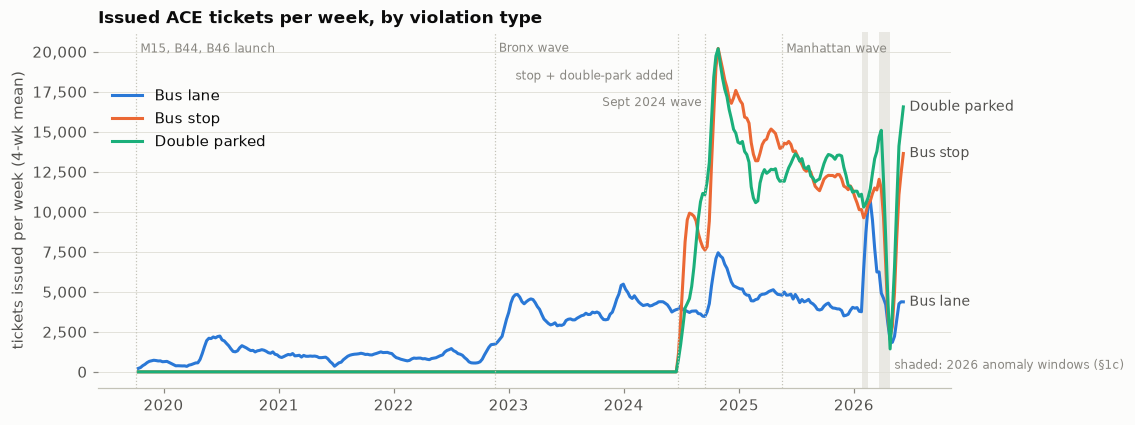

type,Bus lane,Bus stop,Double parked,All
first_occurrence,,,,
2019,"7,561",0,0,"7,561"
2020,"63,446",0,0,"63,446"
2021,"50,909",0,0,"50,909"
2022,"65,649",0,0,"65,649"
2023,"198,509",0,0,"198,509"
2024,"243,879","374,935","354,747","973,561"
2025,"229,982","685,485","653,180","1,568,647"
2026,"118,678","214,818","252,547","586,043"


In [6]:
weekly = (issc.groupby([pd.Grouper(key="first_occurrence", freq="W-SUN"), "type"]).size()
              .unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(10, 4.2))
for t, c in zip(["Bus lane", "Bus stop", "Double parked"], [BLUE, ORANGE, AQUA]):
    s = weekly[t].rolling(4, min_periods=1).mean()
    ax.plot(s.index, s.values, color=c, label=t)
    ax.annotate(t, (s.index[-1], s.values[-1]), xytext=(4, 0), textcoords="offset points",
                color=INK2, va="center", fontsize=9)
ytop = ax.get_ylim()[1]
for d, lab, y, ha in [("2019-10-07", "M15, B44, B46 launch", 0.97, "left"), ("2022-11-18", "Bronx wave", 0.97, "left"),
                      ("2024-06-20", "stop + double-park added", 0.89, "right"), ("2024-09-16", "Sept 2024 wave", 0.81, "right"),
                      ("2025-05-19", "Manhattan wave", 0.97, "left")]:
    ax.axvline(pd.Timestamp(d), color=AXIS, lw=0.8, ls=":")
    ax.text(pd.Timestamp(d), ytop * y, f" {lab} ", color=MUTED, fontsize=8, va="top", ha=ha)
for a, b, _ in ANOMALIES:
    ax.axvspan(a, b, color=GRID, alpha=0.7, lw=0)
ax.yaxis.set_major_formatter(thousands)
ax.set_ylabel("tickets issued per week (4-wk mean)")
ax.set_title("Issued ACE tickets per week, by violation type")
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.88))
ax.text(ANOMALIES[1][1], 0, " shaded: 2026 anomaly windows (§1c)", color=MUTED, fontsize=8, va="bottom")
ax.set_xlim(right=weekly.index[-1] + pd.Timedelta(days=150))
plt.show()
by_year = issc.groupby([issc.first_occurrence.dt.year, "type"]).size().unstack(fill_value=0)
by_year["All"] = by_year.sum(axis=1)
display(by_year.style.format("{:,.0f}"))

### 1e. Concentration by route and by stop

routes with tickets: 66 | top-k share: {1: '9.2%', 3: '25.9%', 5: '36.4%', 10: '57.6%', 20: '81.9%'}
stops with tickets: 4325 | top-k share: {10: '6.4%', 50: '19.2%', 100: '30.0%', 500: '69.1%'}


,tickets,share,activated,tickets_per_day_live
route,,,,
M15+,"323,469",9.2%,2019-10-07,133
BX19,"304,802",8.7%,2022-11-29,237
M101,"282,127",8.0%,2024-09-16,449
BX36,"198,980",5.7%,2023-06-12,182
BX41+,"168,337",4.8%,2022-11-18,130
BX12+,"168,215",4.8%,2022-11-18,130
B46+,"159,550",4.5%,2019-10-31,66
Q44+,"150,030",4.3%,2022-10-03,112
B44+,"140,627",4.0%,2019-10-28,58


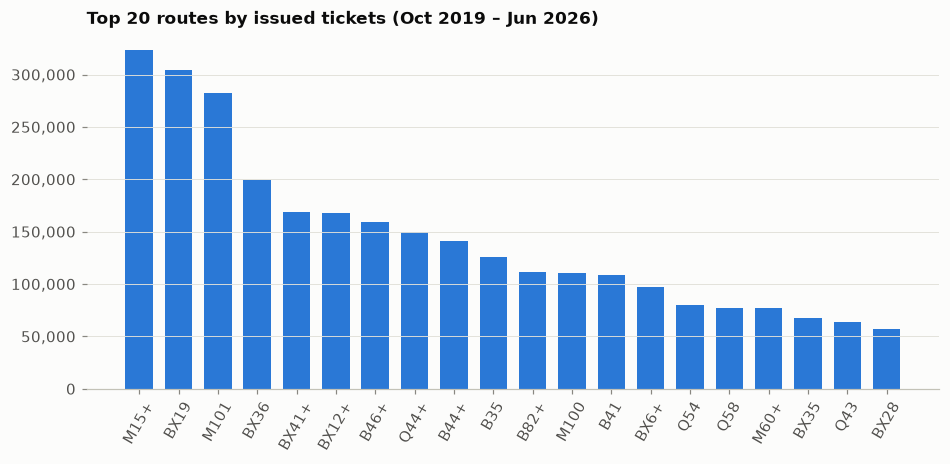

In [7]:
route_tix = issc.groupby("route").size().sort_values(ascending=False)
stop_tix = issc.groupby("stop_id", observed=True).size().sort_values(ascending=False)

def top_share(s, ks):
    return {k: s.head(k).sum() / s.sum() for k in ks}

print("routes with tickets:", len(route_tix), "| top-k share:",
      {k: f"{v:.1%}" for k, v in top_share(route_tix, [1, 3, 5, 10, 20]).items()})
print("stops with tickets:", len(stop_tix), "| top-k share:",
      {k: f"{v:.1%}" for k, v in top_share(stop_tix, [10, 50, 100, 500]).items()})

act = issc.groupby("route").first_occurrence.min()
days_live = (END - act).dt.days.clip(lower=1)
route_table = pd.DataFrame({
    "tickets": route_tix,
    "share": route_tix / route_tix.sum(),
    "activated": act.dt.date,
    "tickets_per_day_live": route_tix / days_live,
}).sort_values("tickets", ascending=False)
route_table.to_csv(os.path.join(DATA, "ace_route_summary.csv"))
display(route_table.head(15).style.format({"tickets": "{:,.0f}", "share": "{:.1%}", "tickets_per_day_live": "{:,.0f}"}))

fig, ax = plt.subplots(figsize=(10, 4.2))
top = route_table.head(20)
ax.bar(top.index, top.tickets, color=BLUE, width=0.7)
ax.yaxis.set_major_formatter(thousands)
ax.set_title("Top 20 routes by issued tickets (Oct 2019 – Jun 2026)")
ax.tick_params(axis="x", rotation=60)
plt.show()

### 1f. When tickets are issued

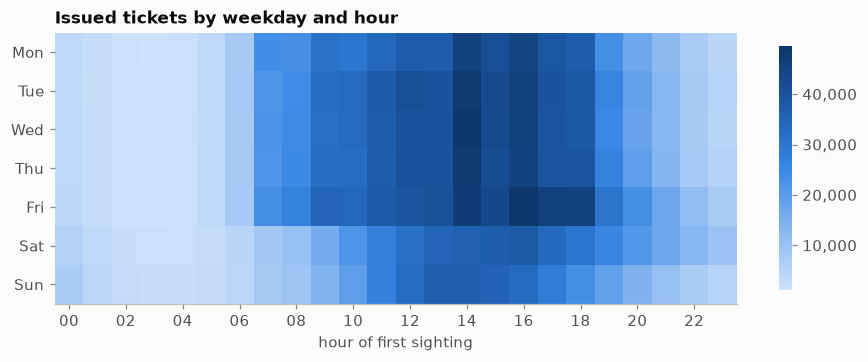

weekend share of tickets: 23.3%


In [8]:
hm = (issc.groupby([issc.first_occurrence.dt.dayofweek, issc.first_occurrence.dt.hour]).size()
          .unstack(fill_value=0))
hm.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(10, 3.2))
im = ax.imshow(hm.values, aspect="auto", cmap=BLUES)
ax.set_yticks(range(7), hm.index); ax.set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
ax.grid(False); ax.set_xlabel("hour of first sighting")
ax.set_title("Issued tickets by weekday and hour")
cb = fig.colorbar(im, ax=ax, format=thousands, shrink=0.9); cb.outline.set_visible(False)
plt.show()
print(f"weekend share of tickets: {issc.first_occurrence.dt.dayofweek.ge(5).mean():.1%}")

### Key findings — profile

- **6.53M camera events, 3.54M issued tickets (54%).** The other 46% are rejected: technical
  issue (13%), missing driver/vehicle info (8%), and four exemption classes (24%), led by
  commercial vehicles under 20 minutes and emergency vehicles.
- **Bus-lane enforcement is now the minority of the program.** From Oct 2019 to June 2024 ACE
  only ticketed bus-lane blocking, on about 20 routes. The June 2024 addition of bus-stop and
  double-parking violations, then the Sept 2024 route waves, took the program from ~200k
  tickets/year to 1.57M in 2025. Bus-lane tickets were only 15% of 2025's total.
- **Concentration is steep.** Of 66 routes with tickets, the top 3 (M15+, BX19, M101) hold
  26%, the top 10 hold 58% and the top 20 hold 82%. At stop level, 100 of 4,325 stops take
  30%. Two Washington Heights / Inwood stops on the BX12+ (Broadway/Isham St and W 207 St/10 Av)
  lead the city with ~32k tickets each.
- **The file's tail is pending, not paused.** Issued tickets stop mid-June 2026 while
  rejected events continue; cut there.
- **Two 2026 anomalies:** a 5-week technical outage (Mar–Apr) and a 3-week citywide
  bus-lane surge (Jan–Feb). Neither is driver behaviour, and both would distort any trend
  that ignored them.

## 2. Repeat offenders

In [9]:
per = iss.groupby("vehicle_id").size()
bins = [1, 2, 3, 4, 5, 6, 11, 21, 51, 101, np.inf]
labels = ["1", "2", "3", "4", "5", "6–10", "11–20", "21–50", "51–100", "101+"]
tier = pd.cut(per, bins, right=False, labels=labels)
dist = pd.DataFrame({"plates": tier.value_counts().sort_index(),
                     "tickets": per.groupby(tier, observed=False).sum()})
dist["plate_share"] = dist.plates / dist.plates.sum()
dist["ticket_share"] = dist.tickets / dist.tickets.sum()
dist.to_csv(os.path.join(DATA, "ace_repeat_distribution.csv"))
display(dist.style.format({"plates": "{:,.0f}", "tickets": "{:,.0f}", "plate_share": "{:.1%}", "ticket_share": "{:.1%}"}))
print(f"{len(per):,} plates; median {per.median():.0f} ticket, 99th pct {per.quantile(.99):.0f}, max {per.max()}")

,plates,tickets,plate_share,ticket_share
1,"810,673","810,673",56.7%,22.9%
2,"262,565","525,130",18.3%,14.8%
3,"126,910","380,730",8.9%,10.7%
4,"70,705","282,820",4.9%,8.0%
5,"43,643","218,215",3.0%,6.2%
6–10,"80,943","595,470",5.7%,16.8%
11–20,"26,543","369,184",1.9%,10.4%
21–50,"7,601","220,764",0.5%,6.2%
51–100,"1,069","71,827",0.1%,2.0%
101+,368,"67,953",0.0%,1.9%


1,431,020 plates; median 1 ticket, 99th pct 16, max 640


### 2a. Choosing the repeat-offender cut

Use the probability that a plate with *k* tickets goes on to get another one. If ticketing
deterred everyone equally this would stay flat. It doesn't: it rises steeply for the first
few tickets and then flattens, and the elbow is the natural boundary between people who
got caught once or twice and habitual offenders.

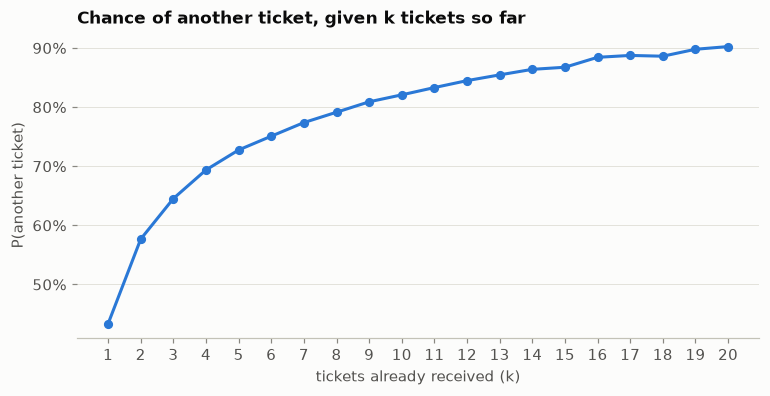

{1: nan, 2: 0.143, 3: 0.069, 4: 0.048, 5: 0.034, 6: 0.023, 7: 0.023, 8: 0.018}


In [19]:
k = np.arange(1, 21)
cont = np.array([(per >= i + 1).sum() / (per >= i).sum() for i in k])
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(k, cont, color=BLUE, marker="o", ms=5)
ax.yaxis.set_major_formatter(pct)
ax.set_xticks(range(1, 21))
ax.set_xlabel("tickets already received (k)"); ax.set_ylabel("P(another ticket)")
ax.set_title("Chance of another ticket, given k tickets so far")
plt.show()
print(pd.Series(cont, index=k).diff().round(3).head(8).to_dict())

The chance of another ticket is 43% after one ticket and 58% after two (+14.3 points). It
reaches 65% after three (+6.9), then climbs by only +4.8, +3.4 and +2.3. The big jumps come
from the first two tickets; from the third on, plates behave alike. **Repeat offender = a plate with more than 2 prior tickets (n = 2)**; this is
the second line in the decay curves. For the behaviour analysis below we use the heavier
**11+ ticket** tier (35.6k plates, 20% of all tickets) so each plate has enough tickets to
show a pattern.

### 2b. One lane or many?

11+ plates: 35,581
median routes per plate: 4; exactly one route: 14.5%
median share on their top route: 64%  (random null: 17%)
>=50% on one route: 67.6% | >=80%: 34.8%
median share at their single top stop: 36%


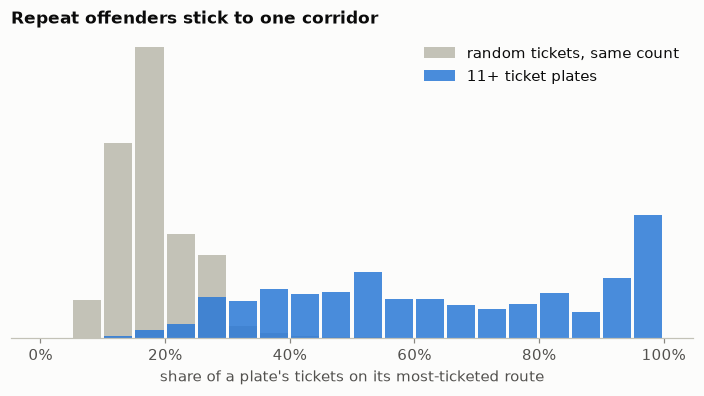

In [11]:
heavy_ids = per[per >= 11].index
h = iss[iss.vehicle_id.isin(heavy_ids)].copy()
h["hour"] = h.first_occurrence.dt.hour
g = h.groupby("vehicle_id")
loyal = pd.DataFrame({
    "n": g.size(),
    "routes": g.route.nunique(),
    "top_route": g.route.agg(lambda x: x.value_counts().index[0]),
    "top_route_share": g.route.agg(lambda x: x.value_counts(normalize=True).iloc[0]),
    "stops": g.stop_id.nunique(),
    "top_stop_share": g.stop_id.agg(lambda x: x.value_counts(normalize=True).iloc[0]),
})

# null: same number of tickets drawn at random from all issued tickets (keeps the citywide route mix)
rng = np.random.default_rng(0)
all_routes = iss.route.dropna().values
null_share = np.array([pd.Series(all_routes[rng.integers(0, len(all_routes), n)]).value_counts(normalize=True).iloc[0]
                       for n in loyal.n.sample(5000, random_state=0)])

print(f"11+ plates: {len(loyal):,}")
print(f"median routes per plate: {loyal.routes.median():.0f}; exactly one route: {(loyal.routes==1).mean():.1%}")
print(f"median share on their top route: {loyal.top_route_share.median():.0%}  (random null: {np.median(null_share):.0%})")
print(f">=50% on one route: {(loyal.top_route_share>=.5).mean():.1%} | >=80%: {(loyal.top_route_share>=.8).mean():.1%}")
print(f"median share at their single top stop: {loyal.top_stop_share.median():.0%}")

fig, ax = plt.subplots(figsize=(8, 3.6))
b = np.linspace(0, 1, 21)
ax.hist(null_share, bins=b, color=AXIS, label="random tickets, same count", rwidth=0.9, density=True)
ax.hist(loyal.top_route_share, bins=b, color=BLUE, alpha=0.85, label="11+ ticket plates", rwidth=0.9, density=True)
ax.xaxis.set_major_formatter(pct); ax.set_yticks([])
ax.set_xlabel("share of a plate's tickets on its most-ticketed route")
ax.set_title("Repeat offenders stick to one corridor")
ax.legend()
plt.show()

### 2c. Is there a daily or weekly rhythm?

Two tests, each against a null that keeps the route's own schedule so we aren't just
rediscovering enforcement hours:

1. **Gaps.** For consecutive tickets to the same plate on the same route, how often is the
   gap close to a whole number of days (±3h)? Uniform timing gives 25%.
2. **Time window.** On each plate's top route, what share of its tickets fall in its busiest
   2-hour window? Null: shuffle hours among all tickets *on that route*.

same-route gaps of 1–14 days within ±3h of a whole day: 67% (uniform: 25%)
same-route gaps under 1 hour: 0.9% (same car, same stop, twice in an hour)


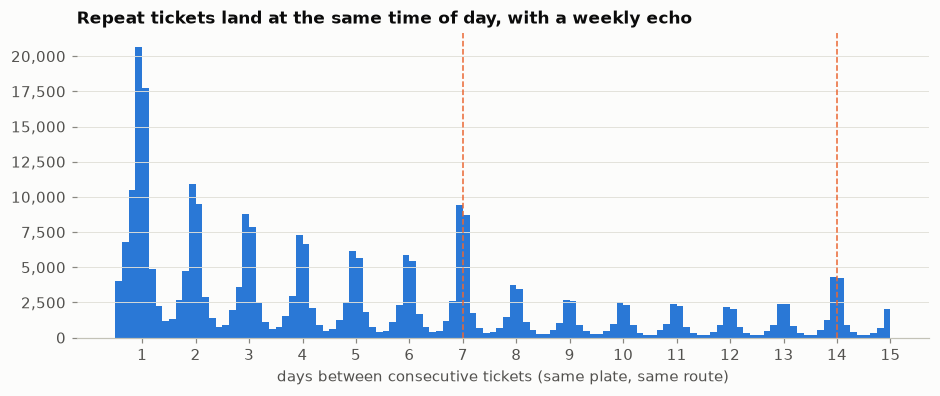

plates with 8+ tickets on top route: 23,451
median share in best 2h window: observed 41%, null 29%
>=50% in one 2h window: observed 36%, null 4%
weekend share: 11+ plates 18% vs all tickets 23%


In [12]:
h = h.sort_values(["vehicle_id", "first_occurrence"])
h["gap_h"] = h.groupby(["vehicle_id", "route"]).first_occurrence.diff().dt.total_seconds() / 3600
gh = h.gap_h.dropna()
multi = gh[(gh >= 21) & (gh <= 14 * 24 + 3)]
on_day = ((multi % 24 <= 3) | (multi % 24 >= 21)).mean()
print(f"same-route gaps of 1–14 days within ±3h of a whole day: {on_day:.0%} (uniform: 25%)")
print(f"same-route gaps under 1 hour: {(gh < 1).mean():.1%} (same car, same stop, twice in an hour)")

fig, ax = plt.subplots(figsize=(10, 3.6))
d = gh[(gh >= 12) & (gh <= 15 * 24)] / 24
ax.hist(d, bins=np.arange(0.5, 15.01, 1 / 8), color=BLUE, rwidth=1.0)
for x in (7, 14):
    ax.axvline(x, color=ORANGE, lw=1, ls="--")
ax.set_xticks(range(1, 16))
ax.yaxis.set_major_formatter(thousands)
ax.set_xlabel("days between consecutive tickets (same plate, same route)")
ax.set_title("Repeat tickets land at the same time of day, with a weekly echo")
plt.show()

# 2-hour window test
top_rt = h.groupby("vehicle_id").route.agg(lambda x: x.value_counts().index[0])
rt = h[h.route == h.vehicle_id.map(top_rt)].copy()
def best2h(hours):
    c = np.bincount(hours, minlength=24)
    return (c + np.roll(c, -1)).max() / len(hours)
obs = rt.groupby("vehicle_id").hour.agg(lambda x: best2h(x.values))
rt["hour_null"] = rt.groupby("route").hour.transform(lambda x: rng.permutation(x.values))
nul = rt.groupby("vehicle_id").hour_null.agg(lambda x: best2h(x.values))
enough = rt.groupby("vehicle_id").size() >= 8
print(f"plates with 8+ tickets on top route: {enough.sum():,}")
print(f"median share in best 2h window: observed {obs[enough].median():.0%}, null {nul[enough].median():.0%}")
print(f">=50% in one 2h window: observed {(obs[enough]>=.5).mean():.0%}, null {(nul[enough]>=.5).mean():.0%}")
wk_rep, wk_all = h.first_occurrence.dt.dayofweek.ge(5).mean(), iss.first_occurrence.dt.dayofweek.ge(5).mean()
print(f"weekend share: 11+ plates {wk_rep:.0%} vs all tickets {wk_all:.0%}")

In [13]:
# The heaviest 15 plates: where and when (hashes truncated)
top15 = loyal.sort_values("n", ascending=False).head(15).copy()
hh = h[h.vehicle_id.isin(top15.index)]
top15["modal_hour"] = hh.groupby("vehicle_id").hour.agg(lambda x: x.mode().iloc[0])
top15["weekday_share"] = hh.groupby("vehicle_id").first_occurrence.agg(lambda x: (x.dt.dayofweek < 5).mean())
top15["top_type"] = hh.groupby("vehicle_id").type.agg(lambda x: x.value_counts().index[0])
top15.index = [v[:8] for v in top15.index]
display(top15.style.format({"top_route_share": "{:.0%}", "top_stop_share": "{:.0%}", "weekday_share": "{:.0%}"}))

,n,routes,top_route,top_route_share,stops,top_stop_share,modal_hour,weekday_share,top_type
7eb12b78,640,3,Q44+,100%,15,56%,11,99%,Bus lane
350b4203,618,2,B25,100%,30,39%,10,100%,Bus lane
c607ad4d,587,4,B25,98%,31,19%,14,99%,Bus lane
485de613,557,1,B44+,100%,20,89%,15,99%,Bus stop
1265d2ab,515,4,BX19,99%,24,31%,14,99%,Bus lane
b680fc68,494,3,Q54,82%,59,18%,14,98%,Bus stop
9fb6696c,492,5,BX41+,69%,15,67%,15,99%,Bus lane
dbb88f9a,478,4,BX12+,98%,18,67%,12,100%,Bus lane
507c8623,463,10,BX12+,44%,66,30%,8,99%,Bus lane
e15cf299,462,1,B82+,100%,10,74%,13,100%,Bus stop


### Key findings — repeat offenders

- **Most plates are caught once.** 57% of plates got one ticket. Plates with 3+ tickets are
  25% of plates but 62% of tickets, and the 2.5% with 11+ tickets hold ~21%.
- **Repeaters are corridor-loyal.** The median heavy repeater gets 64% of its tickets on one
  route, against 17% if those tickets were scattered like everyone else's. A third put 80%+
  on a single route, and the median heavy repeater has 36% of its tickets at a single stop.
  It is the same few blocks, over and over.
- **The heaviest plates look like work vehicles.** Each of the top 15 (418–640 tickets) is
  87–100% weekday, with a modal hour between 07:00 and 15:00. Most concentrate 90%+ on one
  route (Q44+, B25, B44+, BX19, B82+, BX12+).
- **They keep a clock.** Two-thirds of same-route repeat gaps land within ±3h of a whole
  number of days (chance: 25%), with a visible echo at 7 and 14 days. 36% of heavy repeaters
  get at least half of their top-route tickets inside one 2-hour window, against 4% when hours
  are shuffled within the route. They are also less likely to be ticketed at weekends. This
  looks like a commute or a delivery round, not chance.
- **Caveat.** `vehicle_id` is a hashed plate, so a fleet cannot be linked across plates and
  commercial ownership is invisible. The top of the table is very likely fleet vehicles.

## 3. Map

In [14]:
import folium
from folium.plugins import HeatMap

shapes = json.load(open(os.path.join(RAW, "route_shapes.json")))
ALIASES = {"M14+": ["M14A+", "M14D+"], "BX28-BX38": ["BX28", "BX38"], "Q10/Q80": ["Q10", "Q80"], "Q44?+": ["Q44+"]}
def shape_for(route):
    if route in ALIASES:
        return [line for k in ALIASES[route] for line in shapes.get(k, [])] or None
    for key in (route, route.rstrip("+"), route + "+"):
        if key in shapes:
            return shapes[key]
    return None

stops = (issc.groupby("stop_id", observed=True)
             .agg(tickets=("violation_id", "size"), lat=("lat", "median"), lon=("lon", "median"),
                  name=("stop_name", lambda x: x.mode().iloc[0]),
                  route=("route", lambda x: x.mode().iloc[0]),
                  repeat_share=("prior", lambda x: (x > 2).mean()))
             .sort_values("tickets", ascending=False))
stops.to_csv(os.path.join(DATA, "ace_stop_concentration.csv"))
print(f"{len(stops):,} stops; top 100 stops = {stops.tickets.head(100).sum()/stops.tickets.sum():.1%} of tickets")

MAIN = route_table.head(10).index.tolist()
m = folium.Map(location=[40.75, -73.92], zoom_start=11, control_scale=True,
               tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}.png",
               attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> &copy; <a href="https://carto.com/">CARTO</a>')

routes_fg = folium.FeatureGroup(name="All ACE routes", show=True)
main_fg = folium.FeatureGroup(name="Top 10 routes by tickets", show=True)
missing = []
for r in route_table.index:
    shp = shape_for(r)
    if shp is None:
        missing.append(r); continue
    is_main = r in MAIN
    tip = f"<b>{r}</b><br>{route_table.at[r,'tickets']:,} tickets ({route_table.at[r,'share']:.1%})<br>active since {route_table.at[r,'activated']}"
    for line in shp:
        folium.PolyLine(line, color=BLUE if is_main else MUTED, weight=5 if is_main else 1.5,
                        opacity=0.9 if is_main else 0.6, tooltip=tip).add_to(main_fg if is_main else routes_fg)
print("routes without GTFS shape:", missing)

HeatMap(stops[["lat", "lon", "tickets"]].values.tolist(), name="Ticket density", radius=14, blur=18,
        min_opacity=0.25, gradient={0.2: SEQ[1], 0.45: SEQ[3], 0.7: SEQ[5], 1.0: SEQ[6]}, show=False).add_to(m)

pts = stops[stops.tickets >= 200]
qs = pd.qcut(pts.tickets, 5, labels=False, duplicates="drop")
steps = [SEQ[1], SEQ[2], SEQ[3], SEQ[5], SEQ[6]]
marks = folium.FeatureGroup(name=f"Violation locations ({len(pts):,} stops with 200+ tickets)", show=True)
for (sid, row), q in zip(pts.iterrows(), qs):
    folium.CircleMarker(
        [row.lat, row.lon], radius=float(2 + 14 * np.sqrt(row.tickets / pts.tickets.max())),
        color=SURFACE, weight=1, fill=True, fill_color=steps[int(q)], fill_opacity=0.85,
        tooltip=f"<b>{row['name']}</b><br>route {row.route}<br>{row.tickets:,} tickets<br>{row.repeat_share:.0%} to repeat offenders",
    ).add_to(marks)

for fg in (routes_fg, main_fg, marks):
    fg.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
legend = f'''<div style="position:fixed;bottom:24px;left:24px;z-index:9999;background:{SURFACE};padding:10px 12px;
 border:1px solid rgba(11,11,11,.1);border-radius:6px;font:12px system-ui,sans-serif;color:{INK}">
 <b>MTA ACE issued tickets, Oct 2019 – Jun 2026</b><br>
 <span style="display:inline-block;width:18px;height:4px;background:{BLUE};vertical-align:middle"></span> top 10 routes by tickets<br>
 <span style="display:inline-block;width:18px;height:2px;background:{MUTED};vertical-align:middle"></span> other ACE routes<br>
 circles: tickets at the nearest preceding stop, size and shade by count<br>
 <span style="color:{INK2}">light</span> {" ".join(f'<span style="display:inline-block;width:12px;height:12px;background:{c}"></span>' for c in steps)} <span style="color:{INK2}">dark = more tickets</span>
</div>'''
m.get_root().html.add_child(folium.Element(legend))
map_path = os.path.join(OUT, "ace_violations_map.html")
m.save(map_path)
print("saved", os.path.relpath(map_path, ROOT), f"({os.path.getsize(map_path)/1e6:.1f} MB)")

4,325 stops; top 100 stops = 30.0% of tickets
routes without GTFS shape: ['Q6']
saved out/ace_violations_map.html (2.6 MB)


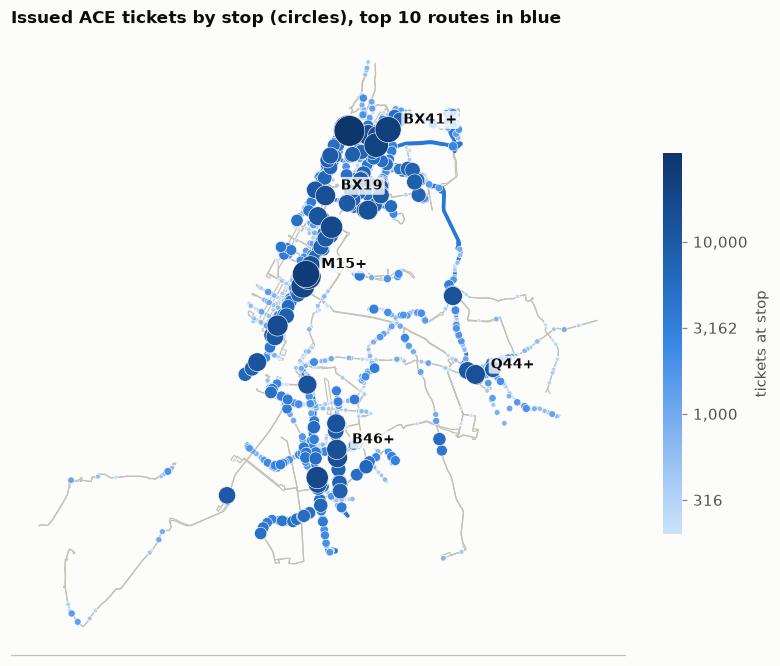

,name,route,tickets,repeat_share
stop_id,,,,
402611,BROADWAY/ISHAM ST,BX12+,"32,771",29%
404170,W 207 ST/10 AV,BX12+,"31,116",25%
401756,2 AV/E 78 ST,M15+,"25,576",30%
102946,WEBSTER AV/BEDFORD PK BL,BX41+,"23,548",21%
401707,1 AV/E 67 ST,M15+,"23,033",27%
104556,WEBSTER AV/E 180 ST,BX41+,"20,677",29%
401704,1 AV/E 57 ST,M15+,"19,259",29%
303477,NOSTRAND AV/NEWKIRK AV,B44+,"17,080",17%
401738,2 AV/E 125 ST,M15+,"17,028",29%


In [15]:
# Static preview of the same map for the notebook
fig, ax = plt.subplots(figsize=(9, 9))
for r in route_table.index:
    shp = shape_for(r)
    if shp is None: continue
    for line in shp:
        a = np.array(line)
        ax.plot(a[:, 1], a[:, 0], color=BLUE if r in MAIN else AXIS, lw=2.2 if r in MAIN else 0.8,
                zorder=3 if r in MAIN else 1)
p = stops[stops.tickets >= 200].sort_values("tickets")
sc = ax.scatter(p.lon, p.lat, s=4 + 400 * p.tickets / p.tickets.max(), c=np.log10(p.tickets), cmap=BLUES,
                edgecolor=SURFACE, linewidth=0.4, zorder=4)
placed = []
for r in MAIN:
    s = stops[stops.route == r].head(1)
    x, y = s.lon.iloc[0], s.lat.iloc[0]
    if any(abs(x - px) < 0.05 and abs(y - py) < 0.03 for px, py in placed):
        continue
    placed.append((x, y))
    ax.annotate(r, (x, y), xytext=(10, 4), textcoords="offset points", fontsize=9,
                color=INK, fontweight="bold", zorder=5,
                bbox=dict(boxstyle="round,pad=0.15", fc=SURFACE, ec="none", alpha=0.8))
ax.set_aspect(1 / np.cos(np.radians(40.7)))
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("Issued ACE tickets by stop (circles), top 10 routes in blue")
cb = fig.colorbar(sc, ax=ax, shrink=0.5); cb.outline.set_visible(False)
cb.set_ticks([2.5, 3, 3.5, 4]); cb.set_ticklabels(["316", "1,000", "3,162", "10,000"]); cb.set_label("tickets at stop")
plt.show()
display(stops.head(12)[["name", "route", "tickets", "repeat_share"]].style.format({"tickets": "{:,.0f}", "repeat_share": "{:.0%}"}))

## 4. Decay curves

**Per camera = per route.** Activation is the route's first issued ticket. The warning
period (the first ~60 days, when only warnings go out) is therefore already excluded.

**What gets counted depends on how the route launched.**
- *Launched before 20 Jun 2024* (bus-lane-only era): count **bus-lane tickets only**. Otherwise
  the June 2024 addition of stop and double-park enforcement shows up as a second activation
  halfway through the curve.
- *Launched from Sep 2024 on:* all three types switched on together, so count all tickets.

**Sufficient history:** at least 52 weeks before `END` and at least 2,000 tickets in the
first year. **Second line:** tickets issued to plates that already had **more than 2** issued
tickets anywhere in the city (the cut from §2a).

Lines are 4-week rolling means. Each panel has its own y-scale, because volumes differ by 100×.
Grey bands mark the two 2026 anomaly windows from §1c. **BX38 ends in Dec 2025**, when its
tickets start being filed under the combined `BX28-BX38` ID.

In [16]:
LEGACY_CUTOFF = pd.Timestamp("2024-06-20")
ROUTE_END = {"BX38": pd.Timestamp("2026-01-01")}
act_all = issc.groupby("route").first_occurrence.min()
series, meta = {}, []
for r, a in act_all.items():
    stop_at = min(END, ROUTE_END.get(r, END))
    s = issc[(issc.route == r) & (issc.first_occurrence < stop_at)]
    cohort = "lane-only launch" if a < LEGACY_CUTOFF else "all-types launch"
    if a < LEGACY_CUTOFF:
        s = s[s.type == "Bus lane"]
    weeks_live = (stop_at - a).days // 7
    first_year = (s.first_occurrence < a + pd.Timedelta(days=365)).sum()
    meta.append((r, a.normalize(), cohort, weeks_live, len(s), first_year))
    wk = ((s.first_occurrence - a).dt.days // 7)
    tot = wk.value_counts().reindex(range(weeks_live), fill_value=0)
    rep = wk[s.prior > 2].value_counts().reindex(range(weeks_live), fill_value=0)
    start = a + pd.to_timedelta(np.arange(weeks_live) * 7, unit="D")
    masked = np.zeros(weeks_live, bool)
    for lo, hi, _ in ANOMALIES:
        masked |= (start + pd.Timedelta(days=7) > lo) & (start < hi)
    series[r] = pd.DataFrame({"all": tot, "repeat": rep, "week_start": start.normalize(), "anomaly": masked})
meta = pd.DataFrame(meta, columns=["route", "activated", "cohort", "weeks_live", "tickets", "first_year"]).set_index("route")
elig = meta[(meta.weeks_live >= 52) & (meta.first_year >= 2000)].sort_values("activated")
print(f"{len(elig)} of {len(meta)} routes have sufficient history")

long = pd.concat({r: series[r] for r in elig.index}, names=["route", "week"]).reset_index()
long["repeat_share"] = long["repeat"] / long["all"].where(long["all"] > 0)
long.to_csv(os.path.join(DATA, "ace_decay_weekly.csv"), index=False)
display(elig.style.format({"tickets": "{:,.0f}", "first_year": "{:,.0f}"}))

32 of 66 routes have sufficient history


,activated,cohort,weeks_live,tickets,first_year
route,,,,,
M15+,2019-10-07 00:00:00,lane-only launch,347,"207,313","45,002"
B44+,2019-10-28 00:00:00,lane-only launch,344,"41,981","4,138"
B46+,2019-10-31 00:00:00,lane-only launch,344,"81,915","7,064"
Q44+,2022-10-03 00:00:00,lane-only launch,191,"61,806","20,551"
BX12+,2022-11-18 00:00:00,lane-only launch,185,"92,899","44,731"
BX41+,2022-11-18 00:00:00,lane-only launch,185,"115,264","49,111"
Q43,2022-11-28 00:00:00,lane-only launch,183,"21,853","5,612"
BX19,2022-11-29 00:00:00,lane-only launch,183,"38,236","11,764"
B25,2022-12-12 00:00:00,lane-only launch,181,"23,613","5,704"


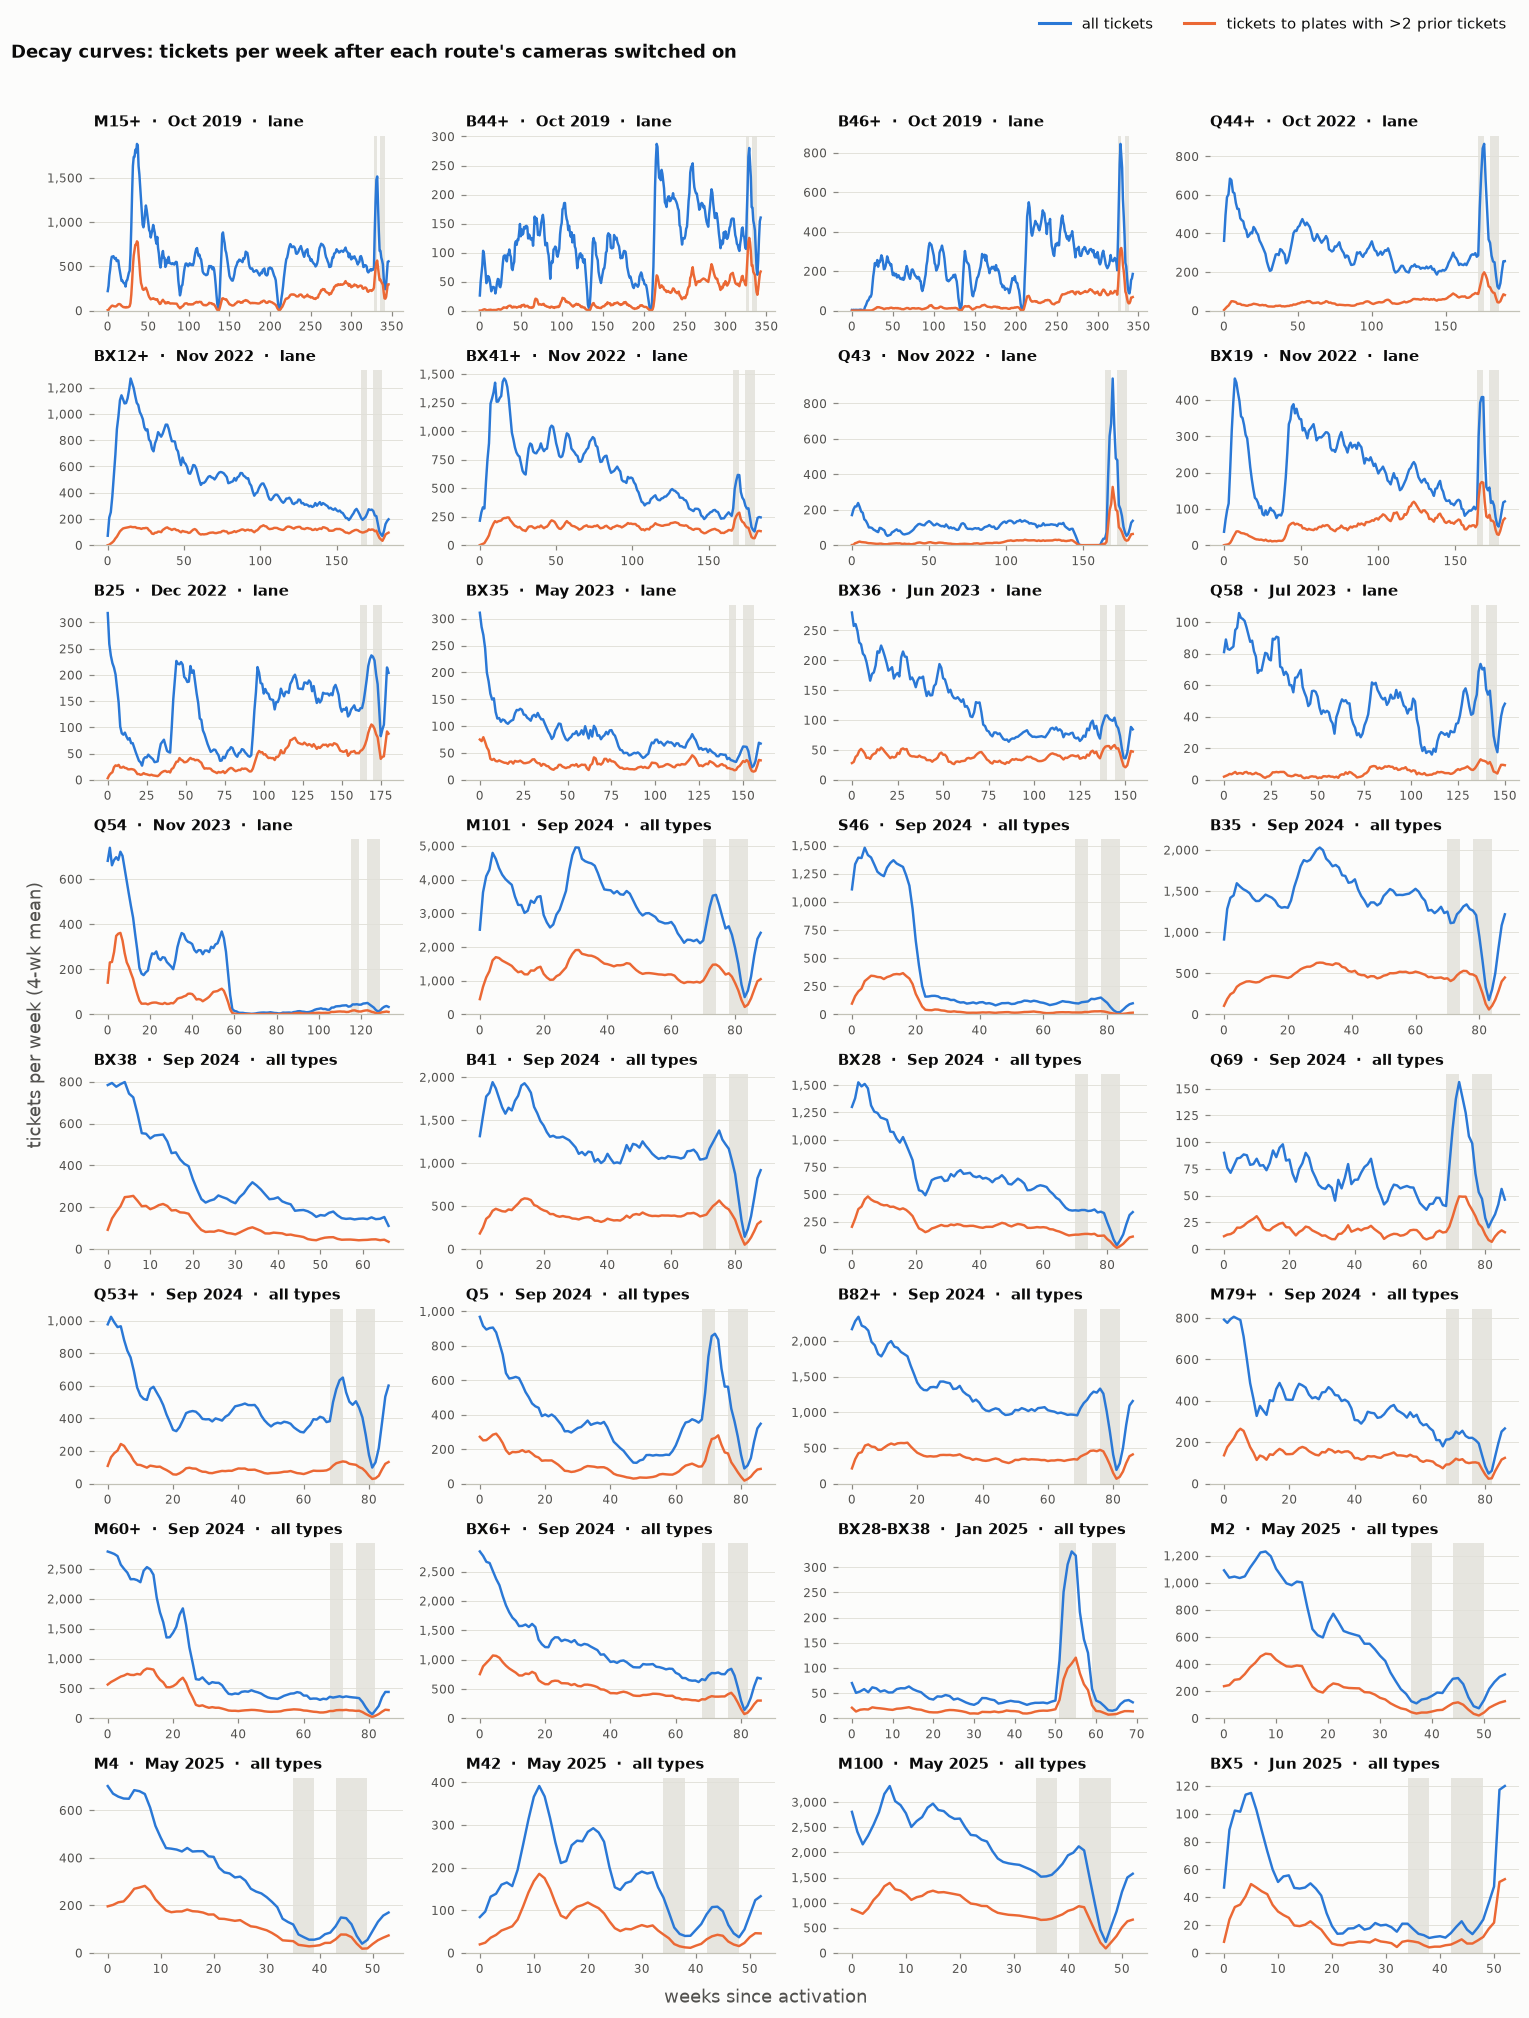

In [17]:
ncol = 4
nrow = int(np.ceil(len(elig) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 2.3 * nrow), sharex=False)
for ax, (r, row) in zip(axes.flat, elig.iterrows()):
    d = series[r][["all", "repeat"]].rolling(4, min_periods=1).mean()
    an = series[r]["anomaly"]
    for blk in (an != an.shift()).cumsum()[an].unique():
        wks = an.index[(an != an.shift()).cumsum() == blk]
        ax.axvspan(wks.min(), wks.max() + 1, color=GRID, alpha=0.8, lw=0)
    ax.plot(d.index, d["all"], color=BLUE, lw=1.6)
    ax.plot(d.index, d["repeat"], color=ORANGE, lw=1.6)
    ax.set_title(f"{r}  ·  {row.activated:%b %Y}  ·  {'lane' if row.cohort.startswith('lane') else 'all types'}",
                 fontsize=9.5)
    ax.yaxis.set_major_formatter(thousands); ax.tick_params(labelsize=8)
    ax.set_ylim(bottom=0)
for ax in axes.flat[len(elig):]:
    ax.set_visible(False)
fig.supxlabel("weeks since activation", color=INK2)
fig.supylabel("tickets per week (4-wk mean)", color=INK2)
fig.legend(handles=[plt.Line2D([], [], color=BLUE, lw=2), plt.Line2D([], [], color=ORANGE, lw=2)],
           labels=["all tickets", "tickets to plates with >2 prior tickets"],
           loc="upper right", ncol=2, bbox_to_anchor=(0.99, 1.0))
fig.suptitle("Decay curves: tickets per week after each route's cameras switched on", x=0.01, ha="left",
             fontweight="bold", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(os.path.join(OUT, "ace_decay_curves.png"), dpi=150)
plt.show()

### Pooled view: the typical route

Each route's weekly total is indexed to its own **weeks 4–11** mean (100 = the level just
after launch). The panel plots the median across routes for the first two years. Weeks inside
the 2026 anomaly windows are dropped before smoothing. A week is shown only when at least 5
routes contribute. Repeat share gets its own panel rather than a second axis.

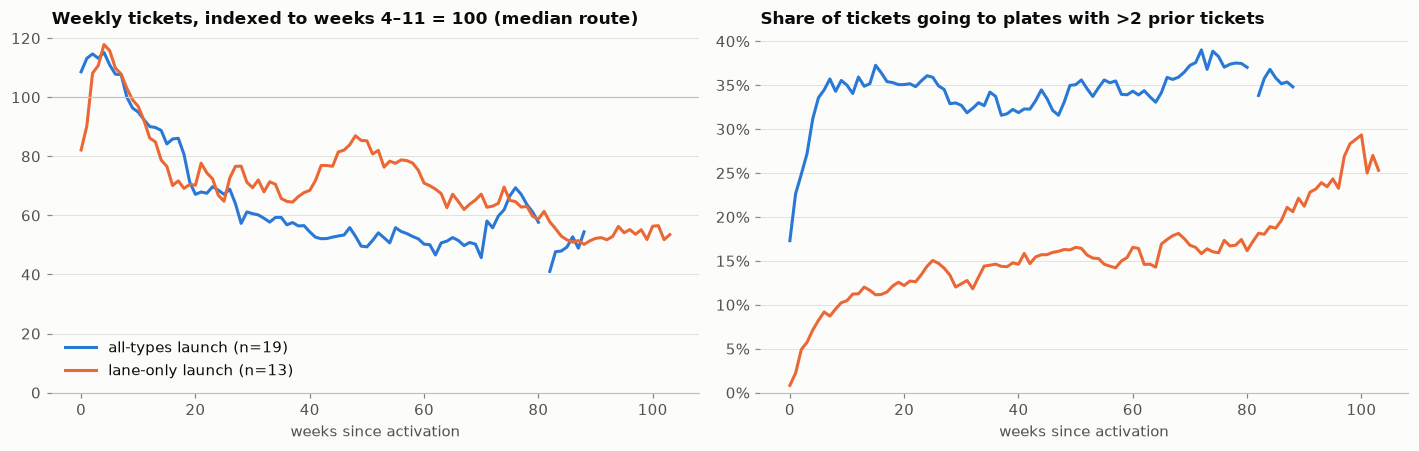

,index_wk24,index_wk52,repeat_share_first_8wk,repeat_share_wk52
cohort,,,,
all-types launch,70,50,34%,36%
lane-only launch,70,81,9%,17%


,index_wk24,index_wk52,repeat_share_first_8wk,repeat_share_wk52,cohort,activated
S46,20,8,23%,18%,all-types launch,2024-09-16 00:00:00
M60+,57,15,29%,33%,all-types launch,2024-09-30 00:00:00
Q5,53,22,32%,25%,all-types launch,2024-09-30 00:00:00
M2,58,27,34%,38%,all-types launch,2025-05-18 00:00:00
BX38,43,27,34%,30%,all-types launch,2024-09-16 00:00:00
M4,60,28,40%,41%,all-types launch,2025-05-19 00:00:00
M42,76,37,37%,40%,all-types launch,2025-05-27 00:00:00
BX6+,70,48,45%,45%,all-types launch,2024-09-30 00:00:00
Q58,81,49,5%,4%,lane-only launch,2023-07-14 00:00:00
M100,78,50,42%,42%,all-types launch,2025-05-27 00:00:00


In [18]:
H = 104
idx, shr = {}, {}
for r in elig.index:
    d = series[r].iloc[:H].copy()
    d.loc[d.anomaly, ["all", "repeat"]] = np.nan
    base = d["all"].iloc[4:12].mean()
    idx[r] = d["all"].rolling(4, min_periods=1).mean() / base * 100
    rs = d["repeat"].rolling(4, min_periods=1).sum() / d["all"].rolling(4, min_periods=1).sum()
    shr[r] = rs
idx, shr = pd.DataFrame(idx), pd.DataFrame(shr)
cohort = elig.cohort

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
for c, col in [("all-types launch", BLUE), ("lane-only launch", ORANGE)]:
    cols = cohort[cohort == c].index
    n_by_week = idx[cols].notna().sum(axis=1)
    med = idx[cols].median(axis=1).where(n_by_week >= 5)
    a1.plot(med.index, med, color=col, label=f"{c} (n={len(cols)})")
    ms = shr[cols].median(axis=1).where(n_by_week >= 5)
    a2.plot(ms.index, ms, color=col, label=c)
a1.axhline(100, color=AXIS, lw=0.8)
a1.set_title("Weekly tickets, indexed to weeks 4–11 = 100 (median route)")
a1.set_xlabel("weeks since activation"); a1.set_ylim(bottom=0)
a2.yaxis.set_major_formatter(pct)
a2.set_title("Share of tickets going to plates with >2 prior tickets")
a2.set_xlabel("weeks since activation"); a2.set_ylim(bottom=0)
a1.legend(loc="lower left")
fig.tight_layout()
fig.savefig(os.path.join(OUT, "ace_decay_pooled.png"), dpi=150)
plt.show()

summ = pd.DataFrame({
    "index_wk24": idx.iloc[20:28].mean(),
    "index_wk52": idx.iloc[48:56].mean(),
    "repeat_share_first_8wk": shr.iloc[4:8].mean(),
    "repeat_share_wk52": shr.iloc[48:56].mean(),
}).join(elig[["cohort", "activated"]])
display(summ.groupby("cohort")[["index_wk24", "index_wk52", "repeat_share_first_8wk", "repeat_share_wk52"]].median()
            .style.format({"index_wk24": "{:.0f}", "index_wk52": "{:.0f}", "repeat_share_first_8wk": "{:.0%}", "repeat_share_wk52": "{:.0%}"}))
summ.to_csv(os.path.join(DATA, "ace_decay_summary.csv"))
display(summ.sort_values("index_wk52").style.format({"index_wk24": "{:.0f}", "index_wk52": "{:.0f}",
        "repeat_share_first_8wk": "{:.0%}", "repeat_share_wk52": "{:.0%}"}))

### Key findings — decay

- **Tickets fall, then level off above zero.** On the median all-types route (19 routes,
  launched Sep 2024 – Jun 2025), weekly tickets are at 70% of their launch level by week 24
  and 50% by week 52. They then hold at roughly half for the rest of the observed period, out
  to about week 80. That is a floor, not deterrence running toward zero — the "toll drivers
  have decided to pay" shape the README hypothesised.
- **Repeat offenders don't drop out faster than anyone else.** On all-types routes, plates
  with more than 2 prior tickets take ~35% of tickets within six weeks of launch, and that
  share stays between 31% and 39% for the next 80 weeks. As volume halves, the habitual share
  of what remains doesn't shrink, which is consistent with enforcement thinning occasional and habitual violators at
  about the same rate.
- **Older, lane-only routes look different, but mostly by construction.** They show the same
  30% first-half-year drop, then drift (81 at week 52, ~55 by week 100) while their repeat
  share climbs from 9% to 25%. Those routes launched when there were few other ACE routes to
  accumulate priors on, so the rise mostly tracks the citywide rollout.
- **Some routes step down instead of decaying.** S46 (Feb 2025, to under 10% of launch), M60+
  (early 2025) and Q54 (Dec 2024, lane) each drop by most of their volume within a few weeks.
  That is an enforcement change — cameras moved, segments dropped, or reclassified — not
  drivers learning. **Unverified**: check MTA service notices before quoting these.
- **At the other end, M15+ and B35 sit at or above their launch level** after a year or more.

### Reading the decay curves — caveats

- **Tickets per week mixes driver behaviour with enforcement effort.** More buses fitted with
  cameras, bus frequency, camera downtime and the rejection rate all move the count. This
  file cannot separate them; that is the same ceiling the README names for the DOF data.
- **The repeat line rises partly by construction.** Prior tickets are counted citywide, so as
  the program grows every plate has had more chances to collect priors elsewhere. A rising
  repeat share on an old route is partly the citywide rollout, not only that route's
  deterrence failing. The all-types cohort, launched into a mature program, is the cleaner
  comparison.
- **Seasonality is not removed.** Each curve runs on calendar time as well as time since
  launch, and the winter dip in §1c shows up inside every curve.

## Summary

See the key-findings cells above and `research/research-log.md` for the dated write-up.
Outputs:

| file | what |
|---|---|
| `out/ace_violations_map.html` | interactive map: routes, top-10 highlighted, stop markers, heat layer |
| `out/ace_decay_curves.png`, `out/ace_decay_pooled.png` | decay figures |
| `data/ace_route_summary.csv` | tickets, share, activation date per route |
| `data/ace_stop_concentration.csv` | tickets per stop with location and repeat share |
| `data/ace_repeat_distribution.csv` | tickets-per-plate tiers |
| `data/ace_decay_weekly.csv`, `data/ace_decay_summary.csv` | weekly decay series and per-route summary |